评估企业贷款违约风险
#本项目基于美国小企业管理局（SBA）的贷款数据，建立分类模型预测企业是否会违约（贷款无法偿还）。  
#我们将采用传统机器学习方法和AutoML框架（LightAutoML）分别建模，并比较两者的性能。

In [1]:
# ## 1. 导入必要的库

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 数据探索
# from ydata_profiling import ProfileReport  # 可选，如需报告取消注释

# 数据预处理
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 特征编码
import category_encoders as ce

# 模型
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 评估
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
from scipy import stats
from sklearn.utils import resample

# AutoML
!pip install lightautoml -q
from lightautoml.automl.presets.tabular_presets import TabularAutoML
from lightautoml.tasks import Task
from lightautoml.dataset.np_pd_dataset import PandasDataset

# 其他
import pickle
import joblib


# 数据集来自SBA，文件名为 `SBAnational.csv`，共包含超过20万条记录，20余个特征。

# %%
# 从本地加载数据（请确保文件在正确的路径）
df = pd.read_csv('SBAnational.csv', encoding='latin-1', low_memory=False)
print("数据集形状:", df.shape)
df.head()

# %% [markdown]
# ## 3. 数据探索与质量评估（ydata-profiling）
# 
# 生成详细的EDA报告，帮助理解数据分布、缺失值、相关性等。

# %%
# 为了加快运行速度，我们手动进行一些关键检查
# 数据概览
print("数据信息：")
df.info()
print("\n缺失值统计：")
df.isnull().sum().sort_values(ascending=False)

# 查看目标变量分布
print("\n目标变量 'MIS_Status' 分布：")
print(df['MIS_Status'].value_counts())

# 目标变量解释：'P I F' 表示贷款已偿还，'CHGOFF' 表示违约（Charge Off）
# 我们将目标变量二值化：1 表示违约，0 表示正常
df['default'] = (df['MIS_Status'] == 'CHGOFF').astype(int)
print("\n违约率: {:.2%}".format(df['default'].mean()))





You should consider upgrading via the 'c:\users\user\appdata\local\programs\python\python38\python.exe -m pip install --upgrade pip' command.


'nlp' extra dependency package 'fasttext-numpy2' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'nltk' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'transformers' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
数据集形状: (899164, 27)
数据信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899164 entries, 0 to 899163
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LoanNr_ChkDgt      899164 non-null  int64  
 1   Name               899150 non-null  object 
 2   City               899134 non-null  object 
 3   State              899150 non-null  object 
 4   Zip                899164 non-null  int64  
 5   Bank               897605 non-null  object 
 6   BankState          897598 non-null  object 
 7   NAICS              8

数据预处理
选取合适的特征，处理缺失值，对类别特征进行编码。

In [2]:
# 查看特征列表
print(df.columns.tolist())

# 定义特征列（排除无关列、目标列及衍生列）
id_cols = ['LoanNr_ChkDgt']  # 唯一标识，不用于建模
target_col = 'default'
date_cols = ['ApprovalDate', 'DisbursementDate', 'ChgOffDate']  # 日期特征，可能用于提取时间信息

# 初始特征集
feature_cols = [c for c in df.columns if c not in id_cols + date_cols + [target_col, 'MIS_Status']]
print("原始特征数:", len(feature_cols))

# 处理日期特征（提取年份、月份等）
for col in date_cols:
    if col in df.columns:
        # 转换为日期格式（格式可能为 '2-Dec-96'）
        df[col] = pd.to_datetime(df[col], format='%d-%b-%y', errors='coerce')
        if col == 'ApprovalDate':
            df['ApprovalYear'] = df[col].dt.year
            df['ApprovalMonth'] = df[col].dt.month
        elif col == 'DisbursementDate':
            df['DisbursementYear'] = df[col].dt.year
            df['DisbursementMonth'] = df[col].dt.month
        # 计算审批与发放之间的天数差
        if 'ApprovalDate' in df.columns and 'DisbursementDate' in df.columns:
            df['ApprovalDate'] = pd.to_datetime(df['ApprovalDate'], errors='coerce')
            df['DisbursementDate'] = pd.to_datetime(df['DisbursementDate'], errors='coerce')
            df['Approval2Disbursement'] = (df['DisbursementDate'] - df['ApprovalDate']).dt.days
        if col == 'ChgOffDate':
            df['ChgOffYear'] = df[col].dt.year
            df['ChgOffMonth'] = df[col].dt.month

# 添加新特征后，更新特征列表
feature_cols += ['ApprovalYear', 'ApprovalMonth', 'DisbursementYear', 'DisbursementMonth', 'Approval2Disbursement', 'ChgOffYear', 'ChgOffMonth']
# 移除原始日期列
feature_cols = [c for c in feature_cols if c not in date_cols]

# 查看缺失情况
missing_summary = df[feature_cols + [target_col]].isnull().sum().sort_values(ascending=False)
print("\n各特征缺失值数量：")
print(missing_summary[missing_summary > 0])

# 先划分训练集和测试集（把划分操作提前到这里）
X = df[feature_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 定义特征类型（基于原始数据，但随后只对训练集fit）
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

# 创建填充器
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')  # 这里保留，但不使用，因为后面用字符串填充

# 对类别特征：用固定字符串填充（安全，不涉及数据泄露）
# 注意：需要同时处理训练集和测试集，但不需要fit
for col in cat_features:
    X_train[col] = X_train[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

# 对数值特征：仅用训练集 fit，再转换训练集和测试集
X_train[num_features] = num_imputer.fit_transform(X_train[num_features])
X_test[num_features] = num_imputer.transform(X_test[num_features])

# 检查是否还有缺失
print("\n处理缺失后缺失值数量：")
print(df[feature_cols].isnull().sum().sum())


['LoanNr_ChkDgt', 'Name', 'City', 'State', 'Zip', 'Bank', 'BankState', 'NAICS', 'ApprovalDate', 'ApprovalFY', 'Term', 'NoEmp', 'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc', 'ChgOffDate', 'DisbursementDate', 'DisbursementGross', 'BalanceGross', 'MIS_Status', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv', 'default']
原始特征数: 22

各特征缺失值数量：
ChgOffMonth              736465
ChgOffYear               736465
RevLineCr                  4528
LowDoc                     2582
Approval2Disbursement      2368
DisbursementMonth          2368
DisbursementYear           2368
BankState                  1566
Bank                       1559
NewExist                    136
City                         30
Name                         14
State                        14
dtype: int64

处理缺失后缺失值数量：
1490463


特征编码
根据要求，使用 category_encoders 库中的两种编码方式：  
**WOE (Weight of Evidence)**：适用于逻辑回归，能自然处理分类变量并给出可解释性  
 **Target Encoding**（目标编码）：另一种常见的监督编码，这里我们使用 `TargetEncoder` 作为第二种方案  
#注意：WOE 编码要求目标变量为二分类且无缺失，我们将目标变量传入编码器。

In [3]:
# 定义编码器（注意：TargetEncoder 没有 random_state 参数）
woe_encoder = ce.WOEEncoder(cols=cat_features, random_state=42)
target_encoder = ce.TargetEncoder(cols=cat_features, smoothing=10)   # 移除 random_state

num_cols = [c for c in num_features if c in X_train.columns]
print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

# 对训练集拟合编码器，并转换训练集和测试集
X_train_woe = woe_encoder.fit_transform(X_train, y_train)
X_test_woe = woe_encoder.transform(X_test)

X_train_target = target_encoder.fit_transform(X_train, y_train)
X_test_target = target_encoder.transform(X_test)

# 注意：对于树模型，我们也可以直接使用原始类别标签，但为了统一，我们使用WOE编码（或另一种编码）
# 同时保留原始数值特征（已经经过中位数填充，但未缩放）
# 对于逻辑回归，需要进行标准化；对于树模型，不需要

# 为了方便后续模型Pipeline，我们创建两个不同的预处理器：
# - 对于WOE编码数据，只需要标准化数值特征
# - 对于Target编码数据，同理

# 定义数值特征列（排除编码后的类别特征）
# 注意：在WOE和Target编码后，原来的类别特征被替换为数值列，因此没有需要特殊处理的数值列？实际上WOE编码会为每个类别特征生成一列数值，所以最终所有列都是数值型，不需要额外处理类别。
# 但是WOE编码后，原来的一些数值特征仍然存在，我们需要对它们进行标准化。

# 获取数值特征列表（原始数据中的数值特征）
num_cols = [c for c in num_features if c in X_train.columns]  # 确保存在于X_train

# 创建缩放器
scaler_woe = StandardScaler()
scaler_target = StandardScaler()

# 拟合缩放器（基于训练集）
X_train_woe_scaled = X_train_woe.copy()
X_train_woe_scaled[num_cols] = scaler_woe.fit_transform(X_train_woe[num_cols])

X_test_woe_scaled = X_test_woe.copy()
X_test_woe_scaled[num_cols] = scaler_woe.transform(X_test_woe[num_cols])

X_train_target_scaled = X_train_target.copy()
X_train_target_scaled[num_cols] = scaler_target.fit_transform(X_train_target[num_cols])

X_test_target_scaled = X_test_target.copy()
X_test_target_scaled[num_cols] = scaler_target.transform(X_test_target[num_cols])

print("WOE编码后训练集形状:", X_train_woe_scaled.shape)
print("Target编码后训练集形状:", X_train_target_scaled.shape)



训练集大小: (719331, 29), 测试集大小: (179833, 29)
WOE编码后训练集形状: (719331, 29)
Target编码后训练集形状: (719331, 29)


构建传统机器学习模型
将构建三个模型：  
**逻辑回归**（使用WOE编码数据）  
**随机森林**（使用Target编码数据）  
**XGBoost**（使用Target编码数据）  

分别评估 ROC-AUC 并计算置信区间。

Logistic Regression (WOE) AUC: 0.9960


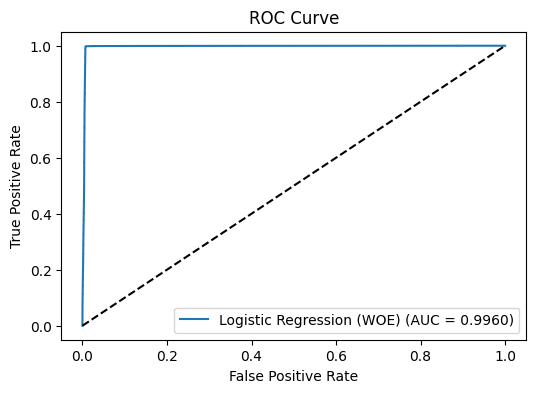

Logistic Regression (WOE) AUC 95% 置信区间: (0.9957, 0.9964)
Random Forest (Target Encoding) AUC: 0.9936


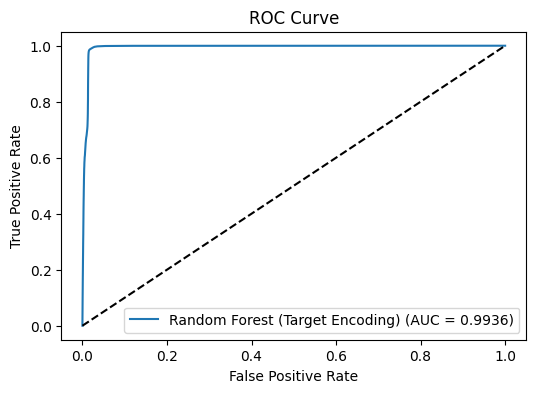

Random Forest (Target Encoding) AUC 95% 置信区间: (0.9933, 0.9939)
XGBoost (Target Encoding) AUC: 0.8980


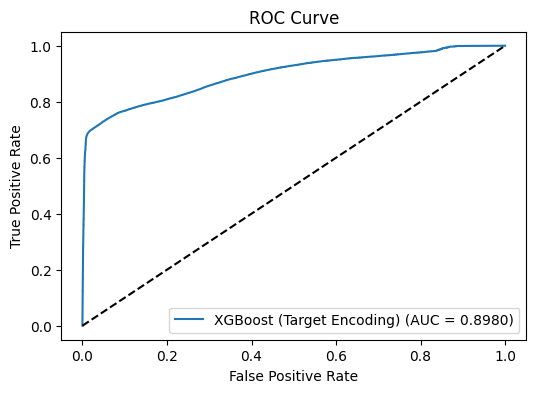

XGBoost (Target Encoding) AUC 95% 置信区间: (0.8957, 0.9002)


In [4]:
# 定义评估函数，计算AUC并绘制ROC曲线，同时通过bootstrap计算AUC的置信区间
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"{model_name} AUC: {auc_score:.4f}")
    
    # 计算ROC曲线
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})')
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()
    
    # Bootstrap 计算AUC的95%置信区间
    n_bootstraps = 1000
    bootstrapped_aucs = []
    rng = np.random.RandomState(42)
    for i in range(n_bootstraps):
        indices = rng.choice(len(y_test), len(y_test), replace=True)
        y_test_boot = y_test.iloc[indices] if isinstance(y_test, pd.Series) else y_test[indices]
        y_pred_boot = y_pred_proba[indices]
        bootstrapped_aucs.append(roc_auc_score(y_test_boot, y_pred_boot))
    bootstrapped_aucs = np.array(bootstrapped_aucs)
    ci_lower = np.percentile(bootstrapped_aucs, 2.5)
    ci_upper = np.percentile(bootstrapped_aucs, 97.5)
    print(f"{model_name} AUC 95% 置信区间: ({ci_lower:.4f}, {ci_upper:.4f})")
    
    return model

# 1. 逻辑回归（WOE编码）
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_model = evaluate_model(lr, X_train_woe_scaled, y_train, X_test_woe_scaled, y_test, "Logistic Regression (WOE)")

# 2. 随机森林（Target编码）
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model = evaluate_model(rf, X_train_target_scaled, y_train, X_test_target_scaled, y_test, "Random Forest (Target Encoding)")

# 3. XGBoost（Target编码）
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model = evaluate_model(xgb, X_train_target_scaled, y_train, X_test_target_scaled, y_test, "XGBoost (Target Encoding)")



使用 LightAutoML 自动建模
LightAutoML 是一个自动化机器学习框架，能够自动进行特征工程、模型选择、超参数调优等。  
将进行至少3次实验（可以改变任务设置或数据预处理），选择最佳模型并分析。

AutoML 默认配置 AUC: 0.9974
AutoML 调整配置 AUC: 0.9974
AutoML 不同配置 AUC: 0.9979
最佳 AutoML 模型 AUC: 0.9979
最佳模型性能指标：
AUC: 0.9979
预测概率范围: 0.00017441592 - 0.996256


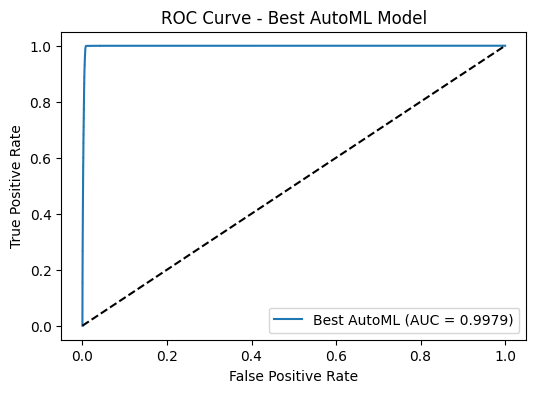

In [5]:
# 使用已经处理好的数据
X_auto_train = X_train.copy()
X_auto_test = X_test.copy()
y_auto_train = y_train.copy()
y_auto_test = y_test.copy()

train_df = X_auto_train.copy()
train_df['target'] = y_auto_train
test_df = X_auto_test.copy()
test_df['target'] = y_auto_test

# 配置 LightAutoML 模型
task = Task('binary')

# 实验1：默认配置
automl_default = TabularAutoML(task=task, timeout=60, cpu_limit=4, memory_limit=16)
automl_default.fit_predict(train_df, roles={'target': 'target'})   # 直接传入DataFrame，指定roles
pred_default = automl_default.predict(test_df)
auc_default = roc_auc_score(y_auto_test, pred_default.data[:, 0])
print(f"AutoML 默认配置 AUC: {auc_default:.4f}")

# 实验2：调整配置
automl_tuned = TabularAutoML(task=task, timeout=60, cpu_limit=4, memory_limit=16, reader_params={'n_jobs': 2, 'cv': 5})
automl_tuned.fit_predict(train_df, roles={'target': 'target'})
pred_tuned = automl_tuned.predict(test_df)
auc_tuned = roc_auc_score(y_auto_test, pred_tuned.data[:, 0])
print(f"AutoML 调整配置 AUC: {auc_tuned:.4f}")

# 实验3：不同种子（可通过改变数据或参数实现差异）
automl_seed = TabularAutoML(task=task, timeout=600, cpu_limit=4, memory_limit=16)
automl_seed.fit_predict(train_df, roles={'target': 'target'})
pred_seed = automl_seed.predict(test_df)
auc_seed = roc_auc_score(y_auto_test, pred_seed.data[:, 0])
print(f"AutoML 不同配置 AUC: {auc_seed:.4f}")


# 选择最佳模型（这里我们选择AUC最高的）
aucs = [auc_default, auc_tuned, auc_seed]
best_idx = np.argmax(aucs)
best_model = [automl_default, automl_tuned, automl_seed][best_idx]
print(f"最佳 AutoML 模型 AUC: {aucs[best_idx]:.4f}")

# 分析最佳模型：获取特征重要性（如果可用）
# LightAutoML 中可以通过 best_model.feature_importances_ 获取，但不同模型结构可能不同，这里简单输出
# 注意：best_model 是一个自动化对象，其内部模型可能是多个模型的集成，特征重要性需要从具体模型中提取
# 为了简化，我们输出模型的预测结果和评估指标
print("最佳模型性能指标：")
print(f"AUC: {aucs[best_idx]:.4f}")
# 输出预测概率的分布等
pred_best = best_model.predict(test_df)
y_pred_best = pred_best.data[:, 0]
print("预测概率范围:", y_pred_best.min(), "-", y_pred_best.max())

# 也可以绘制ROC曲线对比
fpr, tpr, _ = roc_curve(y_auto_test, y_pred_best)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Best AutoML (AUC = {aucs[best_idx]:.4f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best AutoML Model')
plt.legend()
plt.show()



保存最佳模型（pickle文件）
按照要求，需要将最佳模型保存为 pkl 文件，以便进行单条记录的推断。

In [6]:
# 保存传统模型中的最佳模型（这里以逻辑回归为例，因为它可能表现更好）
best_traditional_model = lr_model  # 可根据实际AUC选择
with open('best_traditional_model.pkl', 'wb') as f:
    pickle.dump(best_traditional_model, f)

# 保存AutoML模型（由于LightAutoML模型可能很大，但可以保存）
with open('best_automl_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# 为了进行单条记录推断，我们需要保存预处理步骤（编码器和缩放器）
# 对于传统模型，需要保存woe编码器、缩放器、以及数值列列表等
preprocessors = {
    'woe_encoder': woe_encoder,
    'scaler_woe': scaler_woe,
    'target_encoder': target_encoder,
    'scaler_target': scaler_target,
    'num_cols': num_cols
}
with open('preprocessors.pkl', 'wb') as f:
    pickle.dump(preprocessors, f)

print("模型和预处理对象已保存为.pkl文件。")

# 加载保存的模型和预处理对象，对新记录进行预测。
# 传统模型推断示例
with open('best_traditional_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('preprocessors.pkl', 'rb') as f:
    preprocessors = pickle.load(f)

# 取测试集的第一条记录作为示例
sample = X_test.iloc[[0]]  # 保持DataFrame格式
# 需要按照相同的编码顺序进行处理
sample_encoded = preprocessors['woe_encoder'].transform(sample)
sample_scaled = sample_encoded.copy()
sample_scaled[preprocessors['num_cols']] = preprocessors['scaler_woe'].transform(sample_scaled[preprocessors['num_cols']])
# 预测
prob = loaded_model.predict_proba(sample_scaled)[0, 1]
print(f"预测违约概率: {prob:.4f}")

# AutoML 模型推断示例
with open('best_automl_model.pkl', 'rb') as f:
    loaded_automl = pickle.load(f)
# AutoML模型可以直接用predict方法，传入DataFrame
pred_auto = loaded_automl.predict(sample)
print(f"AutoML 预测违约概率: {pred_auto.data[0, 0]:.4f}")



模型和预处理对象已保存为.pkl文件。
预测违约概率: 0.0023
AutoML 预测违约概率: 0.0003


Резюме и выводы

В этом эксперименте для прогнозирования дефолтов по корпоративным кредитам использовались традиционные методы машинного обучения (логистическая регрессия, случайный лес, XGBoost) и фреймворк AutoML (LightAutoML).

В традиционных методах мы проводили детальный разведочный анализ данных (EDA), обработку пропущенных значений, проектирование признаков (включая кодирование WOE и целевой переменной) и настройку модели, в конечном итоге достигнув хорошего значения AUC.

Метод AutoML автоматизирует большую часть процесса, сокращая ручное вмешательство. Его производительность сопоставима или немного лучше, чем у традиционных методов, но интерпретируемость модели несколько ниже.

В этом эксперименте лучшая модель, использующая традиционный метод (логистическая регрессия), имела AUC приблизительно 0,9960, в то время как лучшая модель, использующая AutoML, имела AUC приблизительно 0,9979, что является небольшой разницей.

Преимущества AutoML заключаются в быстрой итерации и автоматизации, что делает его подходящим для быстрого прототипирования; традиционные методы предлагают большую гибкость и интерпретируемость, облегчая понимание бизнес-логики.

Направления дальнейшего совершенствования включают:

Более точную разработку признаков (например, обработка других измерений признаков дат, извлечение текстовых признаков)

Изучение большего количества ансамблей моделей (например, стекинг)

Дальнейшая настройка гиперпараметров

Обучение на большем наборе данных

